In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"venkatasaieesh","key":"62d6f5ba54e6d3224e66a5e60e1a287d"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 99% 652M/658M [00:01<00:00, 265MB/s]
100% 658M/658M [00:01<00:00, 373MB/s]


In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('plantdisease.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [ ]:
dataset_path = "/content/PlantVillage"

In [ ]:
classes= os.listdir(dataset_path)
print(classes)

['Tomato_Leaf_Mold', 'Tomato__Tomato_mosaic_virus', 'Tomato_Bacterial_spot', 'Pepper__bell___Bacterial_spot', 'Potato___Early_blight', 'Tomato_Septoria_leaf_spot', 'Pepper__bell___healthy', 'Tomato_healthy', 'Tomato__Target_Spot', 'Tomato_Early_blight', 'Potato___healthy', 'Tomato_Late_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Potato___Late_blight']


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

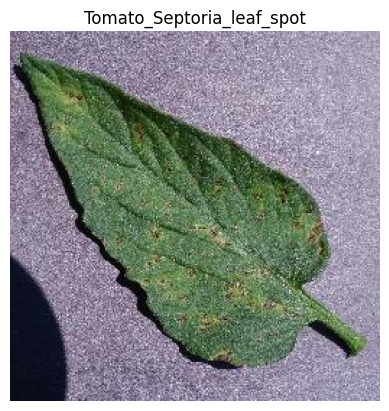

In [ ]:
import random

class_name = random.choice(classes)
folder = os.path.join(dataset_path, class_name)

img = random.choice(os.listdir(folder))
image = cv2.imread(os.path.join(folder, img))

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title(class_name)
plt.axis("off")

In [ ]:
IMG_SIZE =64

data = []
labels = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for img in os.listdir(class_path):
        try:
            image = cv2.imread(os.path.join(class_path, img))
            image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

            data.append(image)
            labels.append(class_name)
        except:
            pass

## STEP 4: ML Baseline Models

In this step, 99 handcrafted features (color, texture, and edge features) are extracted from each image and used to train classical machine learning models such as Logistic Regression, Random Forest, SVM, and KNN.

The purpose is to create a baseline performance using traditional ML methods so it can be compared later with CNN models to demonstrate the advantage of deep learning for image classification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Feature Extraction function
# Extract color, texture, and edge features


def extract_features(image):

  features = []

  # Color information

  for i in range(3):
    hist = cv2.calcHist([image], [i], None, [32], [0, 256])
    features.extend(hist.flatten())

  # Texture information

  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
  features.append(laplacian_var)

  # Edge information

  edges = cv2.Canny(gray, 100, 200)
  features.append(np.mean(edges))
  features.append(np.std(edges))

  return np.array(features)

In [ ]:
# EXTRACT FEATURES FROM ALL IMAGES

print("Extracting features from dataset...")
features_list = []
labels_list = []

for i, (image, label) in enumerate(zip(data, labels)):
    if i % 1000 == 0:
        print(f"Processed {i}/{len(data)} images")

    features = extract_features(image)
    features_list.append(features)
    labels_list.append(label)

X = np.array(features_list)
y = np.array(labels_list)


Extracting features from dataset...
Processed 0/20638 images
Processed 1000/20638 images
Processed 2000/20638 images
Processed 3000/20638 images
Processed 4000/20638 images
Processed 5000/20638 images
Processed 6000/20638 images
Processed 7000/20638 images
Processed 8000/20638 images
Processed 9000/20638 images
Processed 10000/20638 images
Processed 11000/20638 images
Processed 12000/20638 images
Processed 13000/20638 images
Processed 14000/20638 images
Processed 15000/20638 images
Processed 16000/20638 images
Processed 17000/20638 images
Processed 18000/20638 images
Processed 19000/20638 images
Processed 20000/20638 images


In [ ]:
print(f"\nFeature extraction complete!")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")


Feature extraction complete!
Features shape: (20638, 99)
Labels shape: (20638,)


In [ ]:
# ENCODE LABELS
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Classes: {label_encoder.classes_[:5]}...") # Show first 5

# Save label encoder for later use to convert model predictions (numbers) back to class names (strings)
pickle.dump(label_encoder, open('label_encoder.pkl', 'wb'))
print("Label encoder saved!")

Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot' 'Pepper__bell___healthy'
 'Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']...
Label encoder saved!


In [ ]:
# spliting the data
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Training set size: {X_train_ml.shape[0]}")
print(f"Test set size: {X_test_ml.shape[0]}")
print(f"Features per image: {X_train_ml.shape[1]}")

Training set size: 16510
Test set size: 4128
Features per image: 99


In [ ]:
# STANDARDIZE FEATURES
scaler = StandardScaler()
X_train_ml = scaler.fit_transform(X_train_ml)
X_test_ml = scaler.transform(X_test_ml)

print("Features standardized ")

Features standardized 


In [ ]:
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'xgb': XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

ml_results = {}

for name, model in ml_models.items():
    print(f"Training {name}...")
    model.fit(X_train_ml, y_train_ml)

    y_pred = model.predict(X_test_ml)
    accuracy = accuracy_score(y_test_ml, y_pred)

    ml_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }



Training Logistic Regression...
Training Random Forest...
Training SVM...
Training KNN...
Training xgb...


In [ ]:
for name, result in ml_results.items():
    print(f"{name} Accuracy: {result['accuracy']:.4f}")

Logistic Regression Accuracy: 0.7740
Random Forest Accuracy: 0.8442
SVM Accuracy: 0.8835
KNN Accuracy: 0.8324
xgb Accuracy: 0.8951



 ML MODELS COMPARISON
                 Model  Accuracy
4                  xgb  0.895107
2                  SVM  0.883479
1        Random Forest  0.844234
3                  KNN  0.832364
0  Logistic Regression  0.773983



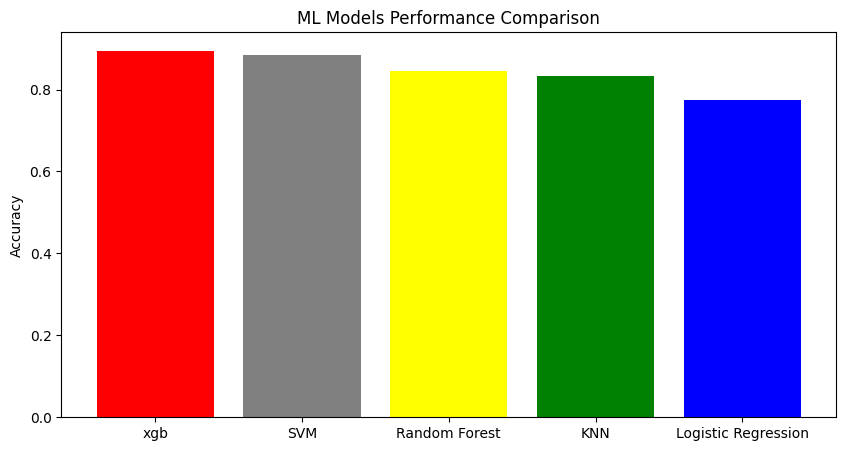

 ML models trained and compared!


In [ ]:
# STEP 4.7: COMPARE ML MODELS

ml_comparison = pd.DataFrame({
    'Model': list(ml_results.keys()),
    'Accuracy': [ml_results[name]['accuracy'] for name in ml_results.keys()]
}).sort_values('Accuracy', ascending=False)

print("\n ML MODELS COMPARISON")
print(ml_comparison)
print()

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(ml_comparison['Model'], ml_comparison['Accuracy'], color=['red', 'grey', 'yellow', 'green','blue'])
plt.ylabel('Accuracy')
plt.title('ML Models Performance Comparison')
plt.show()

print(" ML models trained and compared!")

In [ ]:
# CLASSIFICATION REPORT FOR BEST ML MODEL

best_model_name = ml_comparison.iloc[0]['Model']
best_model = ml_results[best_model_name]['model']
best_pred = ml_results[best_model_name]['predictions']

print(f"\n BEST ML MODEL: {best_model_name}")
print(f"Accuracy: {ml_results[best_model_name]['accuracy']:.4f}\n")
print(classification_report(y_test_ml, best_pred, target_names=label_encoder.classes_))



 BEST ML MODEL: xgb
Accuracy: 0.8951

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.88      0.89      0.89       199
                     Pepper__bell___healthy       0.89      0.89      0.89       296
                      Potato___Early_blight       0.96      0.91      0.93       200
                       Potato___Late_blight       0.82      0.81      0.82       200
                           Potato___healthy       0.79      0.50      0.61        30
                      Tomato_Bacterial_spot       0.91      0.93      0.92       426
                        Tomato_Early_blight       0.78      0.78      0.78       200
                         Tomato_Late_blight       0.84      0.85      0.84       382
                           Tomato_Leaf_Mold       0.95      0.82      0.88       190
                  Tomato_Septoria_leaf_spot       0.89      0.88      0.89       354
Tomato_Spider_mites_Two_s